# Factorization Machine (FM) Recommender System — Algorithm 1

Factorization Machine model for movie recommendations.  
Features: user ID, movie ID, genre multi-hot, year, timestamp (+ TF-IDF in Part 3.2).

## Part 1: Environment Setup

In [1]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [2]:
# GPU check
# The FM model is implemented in PyTorch to leverage GPU acceleration.
# Pure numpy FM would run on CPU only.

if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    DEVICE = torch.device("cpu")
    print("No GPU found — running on CPU")

print(f"Using device: {DEVICE}")

GPU available: NVIDIA GeForce RTX 4090
Memory: 25.3 GB
Using device: cuda:0


In [3]:
# Global hyperparameters
K            = 20       # number of latent factors
LR           = 0.005    # learning rate
LAMBDA       = 0.01     # L2 regularisation strength
EPOCHS       = 50       # max training epochs
PATIENCE     = 5        # early stopping patience (epochs without val RMSE improvement)
BATCH_SIZE   = 1024     # samples per gradient step
RANDOM_STATE = 42       # used for train/val split (same for both models)
RATING_MIN   = 1.0
RATING_MAX   = 5.0

print("Hyperparameters:")
print(f"  k={K}, lr={LR}, λ={LAMBDA}, epochs={EPOCHS}, patience={PATIENCE}, batch_size={BATCH_SIZE}")

Hyperparameters:
  k=20, lr=0.005, λ=0.01, epochs=50, patience=5, batch_size=1024


## Part 2: Load Data & Preprocessing

### Part 2.1: Load CSVs

In [4]:
import os
import pandas as pd

DATA_DIR = os.path.join(os.path.abspath(".."), "flaskr", "static", "ml_data")

ratings_df   = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
movies_df    = pd.read_csv(os.path.join(DATA_DIR, "movie_info.csv"))
genres_df    = pd.read_csv(os.path.join(DATA_DIR, "genre.csv"), delimiter="|", names=["name", "id"])

print(f"Ratings : {ratings_df.shape}  columns: {list(ratings_df.columns)}")
print(f"Movies  : {movies_df.shape}   columns: {list(movies_df.columns)}")
print(f"Genres  : {genres_df.shape}   →  {genres_df['name'].tolist()}")
ratings_df.head(3)

Ratings : (60141, 4)  columns: ['userId', 'movieId', 'rating', 'timestamp']
Movies  : (5446, 7)   columns: ['Unnamed: 0', 'movieId', 'title', 'genres', 'year', 'overview', 'cover_url']
Genres  : (20, 2)   →  ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy', 'Romance', 'Drama', 'Action', 'Thriller', 'Horror', 'Crime', 'Mystery', 'Sci-Fi', 'Musical', 'Documentary', 'War', 'IMAX', 'Western', 'Film-Noir', '(no genres listed)']


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,70,3.0,964982400


### Part 2.2: Feature Engineering

In [5]:
from sklearn.preprocessing import LabelEncoder

# --- userId & movieId: encode to contiguous integer indices ---
user_enc  = LabelEncoder()
movie_enc = LabelEncoder()

ratings_df["user_idx"]  = user_enc.fit_transform(ratings_df["userId"])
ratings_df["movie_idx"] = movie_enc.fit_transform(ratings_df["movieId"])

N_USERS  = ratings_df["user_idx"].max() + 1
N_MOVIES = ratings_df["movie_idx"].max() + 1
print(f"Unique users : {N_USERS}")
print(f"Unique movies: {N_MOVIES}")

Unique users : 485
Unique movies: 5553


In [6]:
ALL_GENRES = genres_df["name"].tolist()  # 20 genres in order

def genre_multihot(genre_str):
    """Convert pipe-separated genre string to 20-dim multi-hot vector."""
    if not isinstance(genre_str, str):
        return [0] * len(ALL_GENRES)
    movie_genres = set(genre_str.split("|"))
    return [1 if g in movie_genres else 0 for g in ALL_GENRES]

# Build genre multi-hot for every movie
movies_df["genre_vec"] = movies_df["genres"].apply(genre_multihot)

# Fill missing years and normalise year to [0, 1]
year_min = movies_df["year"].min()
year_max = movies_df["year"].max()
movies_df["year_norm"] = (movies_df["year"].fillna(movies_df["year"].median()) - year_min) / (year_max - year_min)

# Normalise timestamp to [0, 1]
ts_min = ratings_df["timestamp"].min()
ts_max = ratings_df["timestamp"].max()
ratings_df["ts_norm"] = (ratings_df["timestamp"] - ts_min) / (ts_max - ts_min)

print("Genre multi-hot and normalised features ready.")
print(f"Year range: {int(year_min)} – {int(year_max)}")
print(f"Timestamp range: {ts_min} – {ts_max}")

Genre multi-hot and normalised features ready.
Year range: 1903 – 2018
Timestamp range: 828124615 – 1537799250


### Part 2.3: Build Feature Matrix A (without TF-IDF)

In [7]:
from scipy.sparse import csr_matrix, hstack

# Merge ratings with movie features
merged = ratings_df.merge(movies_df[["movieId", "genre_vec", "year_norm"]], on="movieId", how="left")

n = len(merged)

# Fill missing genre_vec (movies not found in movies_df) with zero vectors
zero_genre = [0] * len(ALL_GENRES)
merged["genre_vec"] = merged["genre_vec"].apply(lambda x: x if isinstance(x, list) else zero_genre)

# Fill missing year_norm with 0
merged["year_norm"] = merged["year_norm"].fillna(0)

# One-hot for users: (n, N_USERS)
user_onehot = csr_matrix(
    ([1.0] * n, (range(n), merged["user_idx"].values)),
    shape=(n, N_USERS)
)

# One-hot for movies: (n, N_MOVIES)
movie_onehot = csr_matrix(
    ([1.0] * n, (range(n), merged["movie_idx"].values)),
    shape=(n, N_MOVIES)
)

# Genre multi-hot: (n, 20)
genre_array = np.array(merged["genre_vec"].tolist(), dtype=np.float32)
genre_matrix = csr_matrix(genre_array)

# Year + timestamp scalars: (n, 2)
scalar_matrix = csr_matrix(
    merged[["year_norm", "ts_norm"]].fillna(0).values.astype(np.float32),
    shape=(n, 2)
)

# Concatenate all → Feature Matrix A
X_A = hstack([user_onehot, movie_onehot, genre_matrix, scalar_matrix], format="csr")
y   = merged["rating"].values.astype(np.float32)

print(f"Feature Matrix A shape : {X_A.shape}")
print(f"  = {N_USERS} users + {N_MOVIES} movies + 20 genres + 2 scalars")
print(f"Target vector y shape  : {y.shape}, range [{y.min()}, {y.max()}]")

Feature Matrix A shape : (60141, 6060)
  = 485 users + 5553 movies + 20 genres + 2 scalars
Target vector y shape  : (60141,), range [0.5, 5.0]


### Part 2.4: Train / Validation Split

In [8]:
from sklearn.model_selection import train_test_split

# Same split indices used for BOTH Model A and Model B (fair comparison)
idx = np.arange(X_A.shape[0])
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)

X_A_train, X_A_val = X_A[train_idx], X_A[val_idx]
y_train,   y_val   = y[train_idx],   y[val_idx]

print(f"Train samples : {len(train_idx)}")
print(f"Val   samples : {len(val_idx)}")

Train samples : 48112
Val   samples : 12029


## Part 3: Models

### Part 3.0: Shared Model Class & Helper Functions
Run this section once before running Part 3.1 or Part 3.2.

In [51]:
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.sparse import issparse

RELEVANCE_THRESHOLD = 3   # rating > 3 is considered relevant
RANKING_EVAL_EVERY  = 5   # compute P@10, R@10, nDCG@10 every N epochs
TOP_K               = 10
ALPHA               = 0.65

class FM(nn.Module):
    """
    Factorization Machine model.
    y = w0 + sum(w_i * x_i) + sum_i sum_{j>i} <v_i, v_j> * x_i * x_j
    Interaction term computed efficiently as:
    0.5 * sum_f [ (sum_i v_if * x_i)^2 - sum_i (v_if * x_i)^2 ]
    """
    def __init__(self, num_features, k):
        super().__init__()
        self.w0 = nn.Parameter(torch.zeros(1))
        self.w  = nn.Parameter(torch.zeros(num_features))
        self.V  = nn.Parameter(torch.randn(num_features, k) * 0.01)

    def forward(self, x):
        linear      = self.w0 + x @ self.w
        xV          = x @ self.V
        interaction = 0.5 * (xV.pow(2).sum(1) - (x.pow(2) @ self.V.pow(2)).sum(1))
        return linear + interaction


def sparse_to_tensor(X_sparse, device):
    """Convert a scipy sparse matrix to a dense float tensor on device."""
    return torch.tensor(X_sparse.toarray(), dtype=torch.float32, device=device)


def compute_ranking_metrics(model, X_split, y_split, split_indices, merged_df, X_full, device, k=TOP_K):
    """
    Compute Precision@k, Recall@k, nDCG@k over the given split.
    For each user in the split: rank all their split items by predicted score,
    then evaluate against their relevant items (rating > RELEVANCE_THRESHOLD).
    """
    model.eval()
    with torch.no_grad():
        X_t    = sparse_to_tensor(X_split, device)
        scores = model(X_t).cpu().numpy()

    split_df = merged_df.iloc[split_indices].copy()
    split_df["score"] = scores

    precisions, recalls, ndcgs = [], [], []

    for _, user_rows in split_df.groupby("userId"):
        relevant = set(user_rows[user_rows["rating"] > RELEVANCE_THRESHOLD]["movieId"].tolist())
        if not relevant:
            continue
        top_k_movies = user_rows.nlargest(k, "score")["movieId"].tolist()
        hits = sum(1 for m in top_k_movies if m in relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))

        dcg  = sum(1 / np.log2(i + 2) for i, m in enumerate(top_k_movies) if m in relevant)
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)


def f1_at_k(p, r):
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)


def composite_score(p, r, ndcg, alpha=ALPHA):
    return alpha * ndcg + (1 - alpha) * f1_at_k(p, r)


def train_fm(model, X_train, y_train, X_val, y_val, device,
             train_indices, val_indices, merged_df,
             epochs=EPOCHS, lr=LR, lam=LAMBDA, batch_size=BATCH_SIZE, patience=PATIENCE):
    """
    Train FM with mini-batch Adam, L2 regularisation, early stopping.
    RMSE logged every epoch. P@10, R@10, nDCG@10 logged every RANKING_EVAL_EVERY epochs.
    Best checkpoint is selected by composite score: alpha*nDCG + (1-alpha)*F1(P,R).
    Returns history dict.
    """
    optimizer     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=lam)
    loss_fn       = nn.MSELoss()
    n_train       = X_train.shape[0]
    history       = {
        "train_rmse": [],
        "val_rmse": [],
        "val_precision": [],
        "val_recall": [],
        "val_ndcg": [],
        "val_comp": [],
        "ranking_epochs": []
    }

    best_comp     = float("-inf")
    best_state    = None
    no_improve    = 0

    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32, device=device)

    for epoch in range(1, epochs + 1):
        model.train()
        perm       = torch.randperm(n_train)
        epoch_loss = 0.0

        for start in range(0, n_train, batch_size):
            idx_b = perm[start: start + batch_size]
            X_b   = sparse_to_tensor(X_train[idx_b.numpy()], device)
            y_b   = y_train_t[idx_b]
            optimizer.zero_grad()
            loss  = loss_fn(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx_b)

        train_rmse = (epoch_loss / n_train) ** 0.5

        model.eval()
        with torch.no_grad():
            X_val_t   = sparse_to_tensor(X_val, device)
            val_preds = model(X_val_t)
            val_rmse  = loss_fn(val_preds, y_val_t).item() ** 0.5

        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        if epoch % RANKING_EVAL_EVERY == 0:
            p, r, n = compute_ranking_metrics(
                model, X_val, y_val, val_indices, merged_df, None, device
            )
            comp = composite_score(p, r, n, alpha=ALPHA)

            history["val_precision"].append(p)
            history["val_recall"].append(r)
            history["val_ndcg"].append(n)
            history["val_comp"].append(comp)
            history["ranking_epochs"].append(epoch)

            print(f"Epoch {epoch:3d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f} "
                  f"| P@10: {p:.4f} | R@10: {r:.4f} | nDCG@10: {n:.4f} | Comp: {comp:.4f}")
        else:
            print(f"Epoch {epoch:3d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

        # Save best model by composite score
        if history["val_comp"]:
            current_comp = history["val_comp"][-1]
            if current_comp > best_comp + 1e-4:
                best_comp  = current_comp
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"Early stopping at epoch {epoch} (no improvement for {patience} ranking checks)")
                    break

    if best_state:
        model.load_state_dict(best_state)
    return history


def evaluate_and_plot(history, model_label):
    """Print final metrics table and plot RMSE + ranking curves."""
    best_epoch      = int(np.argmin(history["val_rmse"])) + 1
    best_val_rmse   = min(history["val_rmse"])
    best_train_rmse = history["train_rmse"][best_epoch - 1]

    print(f"\n{'='*50}")
    print(f"  {model_label} — Best Results (Epoch {best_epoch})")
    print(f"{'='*50}")
    print(f"  Train RMSE : {best_train_rmse:.4f}")
    print(f"  Val   RMSE : {best_val_rmse:.4f}")
    if history["val_precision"]:
        print(f"  Val P@10   : {history['val_precision'][-1]:.4f}")
        print(f"  Val R@10   : {history['val_recall'][-1]:.4f}")
        print(f"  Val nDCG@10: {history['val_ndcg'][-1]:.4f}")
        print(f"  Val Comp   : {history['val_comp'][-1]:.4f}")
    print(f"{'='*50}\n")

    epochs_ran = range(1, len(history["train_rmse"]) + 1)
    fig, axes  = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs_ran, history["train_rmse"], label="Train RMSE")
    axes[0].plot(epochs_ran, history["val_rmse"],   label="Val RMSE")
    axes[0].axvline(best_epoch, linestyle="--", color="gray", label=f"Best epoch {best_epoch}")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("RMSE")
    axes[0].set_title(f"{model_label} — RMSE"); axes[0].legend()

    if history["ranking_epochs"]:
        re = history["ranking_epochs"]
        axes[1].plot(re, history["val_precision"], marker="o", label="P@10")
        axes[1].plot(re, history["val_recall"],    marker="o", label="R@10")
        axes[1].plot(re, history["val_ndcg"],      marker="o", label="nDCG@10")
        axes[1].plot(re, history["val_comp"],      marker="o", label="Composite")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
        axes[1].set_title(f"{model_label} — Ranking Metrics (val)"); axes[1].legend()

    plt.tight_layout()
    plt.show()
    return best_val_rmse, history["val_comp"][-1] if history["val_comp"] else float("nan")


print("FM class and helper functions defined. (RMSE every epoch, P@10/R@10/nDCG@10/Composite every 5 epochs)")

FM class and helper functions defined. (RMSE every epoch, P@10/R@10/nDCG@10/Composite every 5 epochs)


### Part 3.1: FM without TF-IDF

#### Part 3.1.a: Model Setup

In [52]:
NUM_FEATURES_A = X_A.shape[1]
model_A = FM(num_features=NUM_FEATURES_A, k=K).to(DEVICE)
print(f"Model A  →  features={NUM_FEATURES_A}, k={K}")
print(f"Total parameters: {1 + NUM_FEATURES_A + NUM_FEATURES_A * K:,}")

Model A  →  features=6060, k=20
Total parameters: 127,261


#### Part 3.1.b: Training Loop

In [53]:
print("Training Model A (no TF-IDF)...")
history_A = train_fm(
    model_A, X_A_train, y_train, X_A_val, y_val, DEVICE,
    train_indices=train_idx, val_indices=val_idx, merged_df=merged
)

Training Model A (no TF-IDF)...
Epoch   1 | Train RMSE: 2.1830 | Val RMSE: 1.2720
Epoch   2 | Train RMSE: 1.1816 | Val RMSE: 1.1535
Epoch   3 | Train RMSE: 1.1268 | Val RMSE: 1.1166
Epoch   4 | Train RMSE: 1.0986 | Val RMSE: 1.0918
Epoch   5 | Train RMSE: 1.0772 | Val RMSE: 1.0714 | P@10: 0.5808 | R@10: 0.7016 | nDCG@10: 0.8103 | Comp: 0.7491
Epoch   6 | Train RMSE: 1.0600 | Val RMSE: 1.0591
Epoch   7 | Train RMSE: 1.0470 | Val RMSE: 1.0434
Epoch   8 | Train RMSE: 1.0336 | Val RMSE: 1.0342
Epoch   9 | Train RMSE: 1.0237 | Val RMSE: 1.0198
Epoch  10 | Train RMSE: 1.0117 | Val RMSE: 1.0107 | P@10: 0.5846 | R@10: 0.7030 | nDCG@10: 0.8139 | Comp: 0.7525
Epoch  11 | Train RMSE: 1.0026 | Val RMSE: 0.9965
Epoch  12 | Train RMSE: 0.9920 | Val RMSE: 0.9902
Epoch  13 | Train RMSE: 0.9832 | Val RMSE: 0.9790
Epoch  14 | Train RMSE: 0.9749 | Val RMSE: 0.9700
Epoch  15 | Train RMSE: 0.9648 | Val RMSE: 0.9622 | P@10: 0.5949 | R@10: 0.7099 | nDCG@10: 0.8293 | Comp: 0.7656
Epoch  16 | Train RMSE: 0.957

#### Part 3.1.c: Evaluation & Save Weights


  Model A (no TF-IDF) — Best Results (Epoch 45)
  Train RMSE : 0.8951
  Val   RMSE : 0.8909
  Val P@10   : 0.6061
  Val R@10   : 0.7158
  Val nDCG@10: 0.8491
  Val Comp   : 0.7816



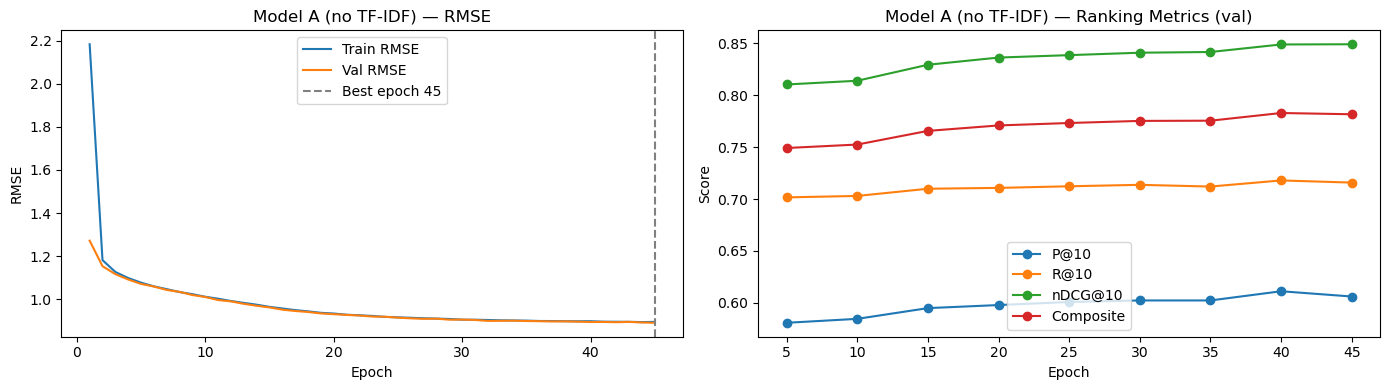

Weights saved → /home/comp/f3228660/COMP4135-RecSys/flaskr/static/ml_data/fm_weights_A.pt


In [54]:
best_rmse_A = evaluate_and_plot(history_A, "Model A (no TF-IDF)")

# Save weights
import os
WEIGHTS_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "flaskr", "static", "ml_data")
os.makedirs(WEIGHTS_DIR, exist_ok=True)
torch.save(model_A.state_dict(), os.path.join(WEIGHTS_DIR, "fm_weights_A.pt"))
print(f"Weights saved → {WEIGHTS_DIR}/fm_weights_A.pt")

### Part 3.2: FM with TF-IDF

#### Part 3.2.a: TF-IDF Extraction & Build Feature Matrix B

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fill missing overviews with empty string
movies_df["overview_clean"] = movies_df["overview"].fillna("")

# Fit TF-IDF on all movie overviews, keep top 500 terms
tfidf_vec = TfidfVectorizer(max_features=500, stop_words="english")
tfidf_matrix_movies = tfidf_vec.fit_transform(movies_df["overview_clean"])  # (n_movies, 500)

# Map each rating row to its movie's TF-IDF vector via movieId index
movie_id_to_row = {mid: i for i, mid in enumerate(movies_df["movieId"].values)}
tfidf_row_indices = merged["movieId"].map(movie_id_to_row).fillna(-1).astype(int).values

# Build TF-IDF rows for each interaction (use zero vector for missing movies)
tfidf_for_ratings = tfidf_matrix_movies[tfidf_row_indices.clip(0)]  # (n, 500)
# Zero out rows where movie wasn't found
missing_mask = tfidf_row_indices < 0
if missing_mask.any():
    tfidf_for_ratings = tfidf_for_ratings.tolil()
    for i in np.where(missing_mask)[0]:
        tfidf_for_ratings[i] = 0
    tfidf_for_ratings = tfidf_for_ratings.tocsr()

# Append TF-IDF to Feature Matrix A → Feature Matrix B
X_B = hstack([X_A, tfidf_for_ratings], format="csr")

print(f"Feature Matrix B shape : {X_B.shape}")
print(f"  = {X_A.shape[1]} (Matrix A) + 500 (TF-IDF) = {X_B.shape[1]}")

# Apply same split
X_B_train, X_B_val = X_B[train_idx], X_B[val_idx]
print(f"Train: {X_B_train.shape} | Val: {X_B_val.shape}")

Feature Matrix B shape : (60141, 6560)
  = 6060 (Matrix A) + 500 (TF-IDF) = 6560
Train: (48112, 6560) | Val: (12029, 6560)


#### Part 3.2.b: Model Setup

In [56]:
NUM_FEATURES_B = X_B.shape[1]
model_B = FM(num_features=NUM_FEATURES_B, k=K).to(DEVICE)
print(f"Model B  →  features={NUM_FEATURES_B}, k={K}")
print(f"Parameters: w0=1, w={NUM_FEATURES_B}, V={NUM_FEATURES_B}×{K}  "
      f"→ total {1 + NUM_FEATURES_B + NUM_FEATURES_B * K:,}")

Model B  →  features=6560, k=20
Parameters: w0=1, w=6560, V=6560×20  → total 137,761


#### Part 3.2.c: Training Loop

In [57]:
print("Training Model B (with TF-IDF)...")
history_B = train_fm(
    model_B, X_B_train, y_train, X_B_val, y_val, DEVICE,
    train_indices=train_idx, val_indices=val_idx, merged_df=merged
)

Training Model B (with TF-IDF)...
Epoch   1 | Train RMSE: 1.8971 | Val RMSE: 1.1084
Epoch   2 | Train RMSE: 1.0905 | Val RMSE: 1.0763
Epoch   3 | Train RMSE: 1.0668 | Val RMSE: 1.0601
Epoch   4 | Train RMSE: 1.0529 | Val RMSE: 1.0439
Epoch   5 | Train RMSE: 1.0393 | Val RMSE: 1.0332 | P@10: 0.5819 | R@10: 0.7031 | nDCG@10: 0.8076 | Comp: 0.7478
Epoch   6 | Train RMSE: 1.0285 | Val RMSE: 1.0267
Epoch   7 | Train RMSE: 1.0180 | Val RMSE: 1.0164
Epoch   8 | Train RMSE: 1.0107 | Val RMSE: 1.0065
Epoch   9 | Train RMSE: 1.0010 | Val RMSE: 0.9981
Epoch  10 | Train RMSE: 0.9954 | Val RMSE: 0.9899 | P@10: 0.5808 | R@10: 0.7029 | nDCG@10: 0.8107 | Comp: 0.7495
Epoch  11 | Train RMSE: 0.9845 | Val RMSE: 0.9852
Epoch  12 | Train RMSE: 0.9796 | Val RMSE: 0.9736
Epoch  13 | Train RMSE: 0.9714 | Val RMSE: 0.9684
Epoch  14 | Train RMSE: 0.9659 | Val RMSE: 0.9609
Epoch  15 | Train RMSE: 0.9576 | Val RMSE: 0.9588 | P@10: 0.5901 | R@10: 0.7081 | nDCG@10: 0.8254 | Comp: 0.7618
Epoch  16 | Train RMSE: 0.9

#### Part 3.2.d: Evaluation & Save Weights


  Model B (with TF-IDF) — Best Results (Epoch 30)
  Train RMSE : 0.9054
  Val   RMSE : 0.9047
  Val P@10   : 0.6019
  Val R@10   : 0.7140
  Val nDCG@10: 0.8370
  Val Comp   : 0.7727



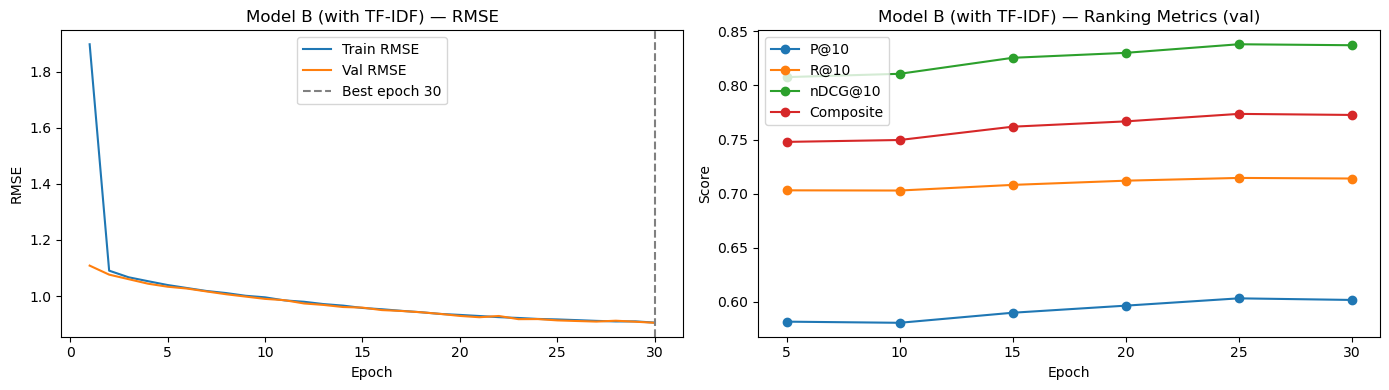

Weights saved → /home/comp/f3228660/COMP4135-RecSys/flaskr/static/ml_data/fm_weights_B.pt


In [58]:
best_rmse_B = evaluate_and_plot(history_B, "Model B (with TF-IDF)")

torch.save(model_B.state_dict(), os.path.join(WEIGHTS_DIR, "fm_weights_B.pt"))
print(f"Weights saved → {WEIGHTS_DIR}/fm_weights_B.pt")

## Part 4 — Model Comparison: A (no TF-IDF) vs B (with TF-IDF)

In [50]:

# ── 4.1  Side-by-side metrics table ──────────────────────────────────────────
import pandas as pd

def best_ranking(history, metric):
    vals = history.get(metric, [])
    return max(vals) if vals else float("nan")

rows = []
for label, h, best_rmse in [
    ("Model A (no TF-IDF)",  history_A, best_rmse_A),
    ("Model B (with TF-IDF)", history_B, best_rmse_B),
]:
    rows.append({
        "Model":          label,
        "Best Val RMSE":  round(best_rmse, 4),
        "Best P@10":      round(best_ranking(h, "val_precision"), 4),
        "Best R@10":      round(best_ranking(h, "val_recall"),    4),
        "Best nDCG@10":   round(best_ranking(h, "val_ndcg"),      4),
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
print(comparison_df.to_string())


TypeError: type tuple doesn't define __round__ method

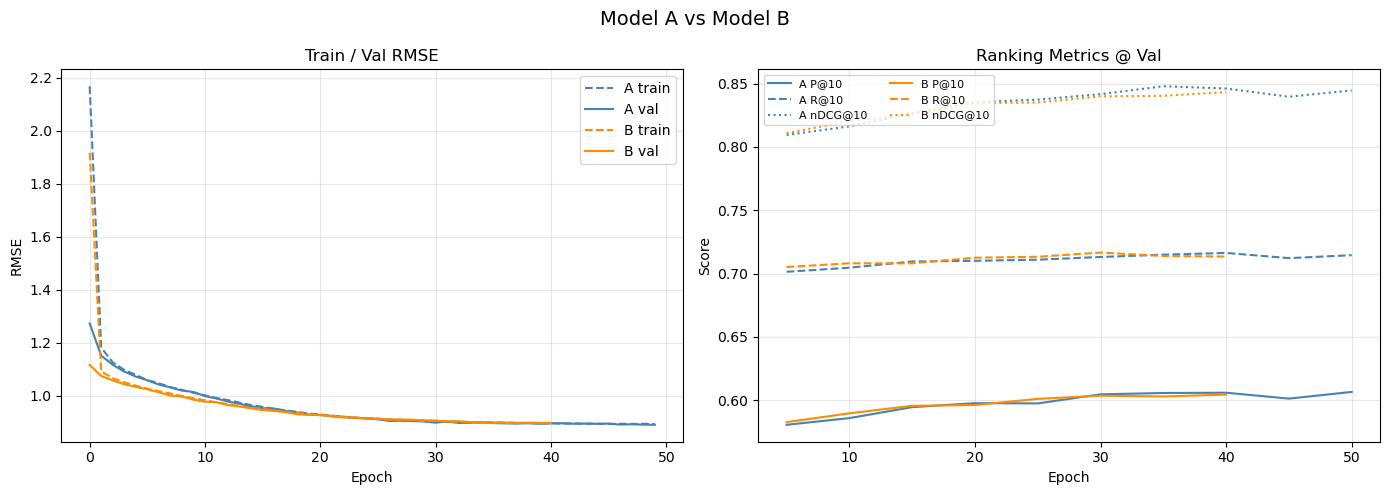

Saved comparison_AB.png


In [ ]:

# ── 4.2  Overlay plots ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model A vs Model B", fontsize=14)

# --- RMSE curves ---
ax = axes[0]
ax.plot(history_A["train_rmse"], label="A train", linestyle="--", color="steelblue")
ax.plot(history_A["val_rmse"],   label="A val",   linestyle="-",  color="steelblue")
ax.plot(history_B["train_rmse"], label="B train", linestyle="--", color="darkorange")
ax.plot(history_B["val_rmse"],   label="B val",   linestyle="-",  color="darkorange")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.set_title("Train / Val RMSE")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Ranking metrics curves ---
ax = axes[1]
r_epochs = history_A["ranking_epochs"]
ax.plot(r_epochs, history_A["val_precision"], label="A P@10",    linestyle="-",  color="steelblue")
ax.plot(r_epochs, history_A["val_recall"],    label="A R@10",    linestyle="--", color="steelblue")
ax.plot(r_epochs, history_A["val_ndcg"],      label="A nDCG@10", linestyle=":",  color="steelblue")
r_epochs_b = history_B["ranking_epochs"]
ax.plot(r_epochs_b, history_B["val_precision"], label="B P@10",    linestyle="-",  color="darkorange")
ax.plot(r_epochs_b, history_B["val_recall"],    label="B R@10",    linestyle="--", color="darkorange")
ax.plot(r_epochs_b, history_B["val_ndcg"],      label="B nDCG@10", linestyle=":",  color="darkorange")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Ranking Metrics @ Val")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_AB.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved comparison_AB.png")


In [ ]:
# ── 4.3  Conclusion: pick the better model ────────────────────────────────────
best_comp_A = max(history_A["val_comp"]) if history_A["val_comp"] else float("nan")
best_comp_B = max(history_B["val_comp"]) if history_B["val_comp"] else float("nan")

winner = "A (no TF-IDF)" if best_comp_A >= best_comp_B else "B (with TF-IDF)"

print(f"Best Composite — Model A: {best_comp_A:.4f}  |  Model B: {best_comp_B:.4f}")
print(f"→ Deploying Model {winner} to algo1.py")

Best Val RMSE — Model A: 0.8913  |  Model B: 0.8982
→ Deploying Model A (no TF-IDF) to algo1.py
